# Traffic Simulation with Monte Carlo
**Module:** Simulationstools
**Students/Authors:** Michaela Nofski, Zobia Ahmad




## Model idea

Each simulation run represents one possible traffic scenario on a simplified one-dimensional road segment.

At the beginning of each run, vehicles are assigned random initial positions and random initial speeds, which introduces uncertainty into the system. The dynamics of the traffic flow are evaluated based on these random inputs.

The output of a single simulation run is a scalar summary statistic, namely the average speed of all vehicles. This quantity serves as a proxy for the overall traffic flow quality.

By repeating the simulation many times with independent random seeds, we apply a Monte Carlo approach to estimate the expected average speed and to quantify the uncertainty of this estimate using the standard error.




## 1. Imports & RNG

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED) 

ROAD_LENGTH = 1000.0
DT = 0.1
N_STEPS = 1000
N_MC = 500


## 2. Model: Single Simulation Run
Before performing the Monte Carlo experiment, we define a single simulation run. One run represents one possible traffic scenario and returns a single scalar output, namely the average speed of all vehicles.

In [2]:
def run_single_simulation(n_cars, n_steps, road_length, rng):
    speeds = rng.normal(loc=30.0, scale=5.0, size=n_cars) 
    speeds = np.clip(speeds, 0.0, None) 

    for _ in range(n_steps):
        pass

    return np.mean(speeds)
    

## 3. Sanity Check: Single Run

In [6]:
test_result = run_single_simulation( 
    n_cars=50,
    n_steps=100,
    road_length=ROAD_LENGTH,
    rng=rng
) 
print (test_result)

29.743855155971037


## 4. Monte Carlo Experiment
In this section, the traffic simulation is repeated many times with independent random seeds. Each simulation run produces one estimate of the average vehicle speed. The collection of these estimates is used to approximate the expected value of the average speed and to quantify uncertainty via the standard error.

In [7]:
def monte_carlo_simulation(n_runs, n_cars, n_steps, road_length, rng):
    results = []
    
    for _ in range(n_runs):
        avg_speed = run_single_simulation( 
            n_cars=n_cars,
            n_steps=n_steps,
            road_length=road_length,
            rng=rng
        ) 
        results.append(avg_speed)
    return np.array(results)


In [8]:
results = monte_carlo_simulation(
    n_runs=10_000,
    n_cars=100,
    n_steps=N_STEPS,
    road_length=ROAD_LENGTH,
    rng=rng
)

results[:5]


array([29.77129084, 30.32923281, 29.85823895, 29.97514458, 29.44987974])

**4.1 Monte Carlo Estimation of the Average Speed**

Using the results from multiple independent simulation runs, we estimate the expected average vehicle speed and quantify the uncertainty of this estimate using the standard error.

In [9]:
mean_speed = results.mean()
std_error = results.std(ddof=1) / np.sqrt(len(results))
ci = (
    mean_speed - 1.96 * std_error,
    mean_speed + 1.96 * std_error
)
mean_speed, std_error, ci

(np.float64(30.00049037713384),
 np.float64(0.0049803062042056215),
 (np.float64(29.990728976973596), np.float64(30.010251777294084)))

**4.2 Monte Carlo Estimates Results / Visualization**

Based on the Monte Carlo simulation results, we compute the estimated expected average traffic speed and its associated standard  error.

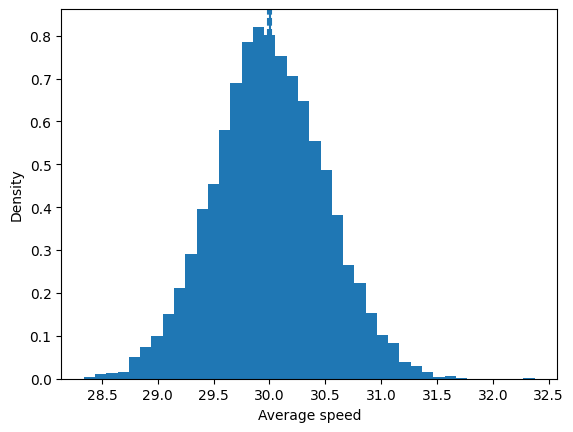

In [10]:
plt.hist(results, bins=40, density=True)
plt.axvline(mean_speed)
plt.axvline(ci[0], linestyle="--")
plt.axvline(ci[1], linestyle="--")

plt.xlabel("Average speed")
plt.ylabel("Density") 
plt.show() 

**4.3. Interpretation (Monte Carlo Experiment)**

The Monte Carlo simulation estimates the expected average traffic speed based on repeated random traffic scenarios. The associated standard error quantifies the uncertainty of this estimate due to the finite number of simulation runs.

The histogram illustrates the distribution of the estimated average speeds and shows moderate variability around the mean, which is consistent with stochastic initial conditions.

## 5. Sensitivity Analysis: Number of vehicles
The goal of this sensitivity analysis is to study how the average traffic speed and the prohability of traffic jam formation depend on the number of vehicles in the system.

In [12]:
vehicle_counts = [10, 20, 40, 60, 80]
num_replications = N_MC

In [14]:
sensitivity_results = {} 

for num_vehicles in vehicle_counts:
    simulation_outputs = [] 
    
    for r in range(num_replications):
        rng_rep = np.random.default_rng(1000 + r) 

        mean_speed = run_single_simulation(  
            n_cars=num_vehicles,
            n_steps=N_STEPS,
            road_length=ROAD_LENGTH,
            rng=rng_rep
        ) 
        simulation_outputs.append(mean_speed) 
    sensitivity_results[num_vehicles] = np.array(simulation_outputs) 
               
        

**5.1 Sensitivity Analyisis - Auswertung**

**5.1.1 Mittelwert & Standardfehler pro Fahrzeuganzahl**

In [15]:
sens_means = {} 
sens_se = {} 
for n_cars, values in sensitivity_results.items():
    sens_means[n_cars] = values.mean() 
    sens_se[n_cars] = values.std(ddof=1) / np.sqrt(len(values))

sens_means, sens_se

({10: np.float64(30.03893422956026),
  20: np.float64(29.927665135375545),
  40: np.float64(29.99027218909766),
  60: np.float64(29.992182173415625),
  80: np.float64(29.98868231308057)},
 {10: np.float64(0.07173357765662912),
  20: np.float64(0.04816696260369447),
  40: np.float64(0.03487669699489268),
  60: np.float64(0.02895913123566751),
  80: np.float64(0.025232628139813244)})

**5.1.2 Sensitivity Plot**

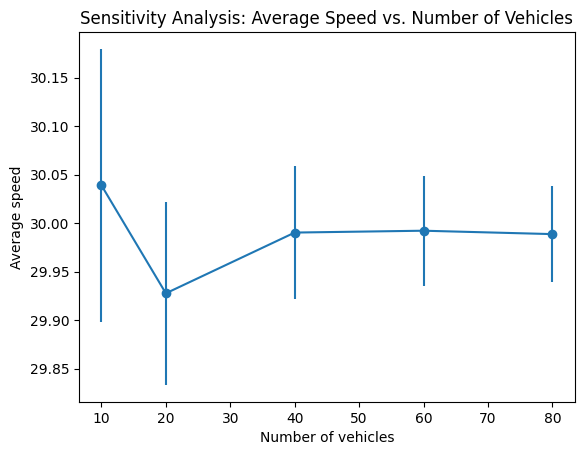

In [19]:
x = list(sens_means.keys())
y = [sens_means[n] for n in x] 
yerr = [1.96 * sens_se[n] for n in x] 

plt.errorbar(x, y, yerr=yerr, fmt="o-") 
plt.xlabel("Number of vehicles") 
plt.ylabel("Average speed") 
plt.title("Sensitivity Analysis: Average Speed vs. Number of Vehicles") 
plt.show() 


**5.2 Interpretation (Sensitivity Analysis)**

The sensitivity analysis shows how the expected average vehicle speed depends on the number of vehicles in the system. For each scenario, the mean speed is estimated using Monte Carlo simulation and uncertainty is quantified via the standard error.

Overall, the results suggest a slight tendency towards lower average speeds for larger numbers of vehicles; however, the effect is small and the confidence intervals largely overlap, indicating only weak congestion effects in this simplified model.

## 6. Limitations

The traffic model is deliberately simplified and does not include vehicle interactions, overtaking, or explicit congestion dynamics. As a result, the observed sensitivity effects are small and mainly driven by stochastic initial conditions rather than emergent traffic jams. More realistic dynamics would likely amplify congestion effects.

## 7. Summary
In this project, a Monte Carlo traffic simulation was implemented to estimate the expected average vehicle speed under stochastic initial conditions. Uncertainty was quantified using the standard error and confidence intervals. 

A sensitivity analysis with respect to the number of vehicles was conducted, showing only weak congestion effects due to the simplified model structure.
